# GeoSpectra AI

## Notebook 02 - Data Visualization

### Objectives

- Load the hyperspectral cube
- Verify the reflectance values
- Explore the wavelength distribution
- Display RGB and false colour composites
- Inspecet individual bands

In [3]:
#2_import libraries
import h5py
import numpy as np

import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams["figure.figsize"] = (10,8)
plt.rcParams["image.cmap"] = "gray"

DATA_PATH = Path(r"C:\GIS_Work\5 GeoSpectra AI\data\raw\20250824_171857_84_4001_ortho_sr_hdf5.h5")


In [4]:
#3_Load the Hyperspectral data cube
with h5py.File(DATA_PATH, "r") as f:

    cube = f["HDFEOS/GRIDS/HYP/Data Fields/surface_reflectance"][:]

    wavelengths = f["HDFEOS/GRIDS/HYP/Data Fields/surface_reflectance"].attrs["wavelengths"]

print("Cube shape:", cube.shape)
print("Datatype:", cube.dtype)

Cube shape: (426, 671, 763)
Datatype: float32


In [7]:
#4_Replace fill values
fill_value = -9999.0

cube = cube.astype(np.float32)

cube[cube == fill_value] = np.nan

print("Fill values converted to NaN.")

Fill values converted to NaN.


In [8]:
#5_Inspect the data in the cube
print("="*50)
print("Reflectance Statistics")
print("="*50)

print("Minimum:", np.nanmin(cube))
print("Maximum:", np.nanmax(cube))
print("Mean:", np.nanmean(cube))
print("Std Dev:", np.nanstd(cube))

Reflectance Statistics
Minimum: -15.859816
Maximum: 23.711105
Mean: 0.17651087
Std Dev: 0.16442646


In [10]:
#6_Check number of valid pixels in cube
total_pixels = cube.size

valid_pixels = np.count_nonzero(~np.isnan(cube))

nan_pixels = np.count_nonzero(np.isnan(cube))

print(f"Total values : {total_pixels:,}")
print(f"Valid values : {valid_pixels:,}")
print(f"NoData values : {nan_pixels:,}")

print(f"Valid % : {100*valid_pixels/total_pixels:.2f}%")

Total values : 218,100,498
Valid values : 155,609,706
NoData values : 62,490,792
Valid % : 71.35%


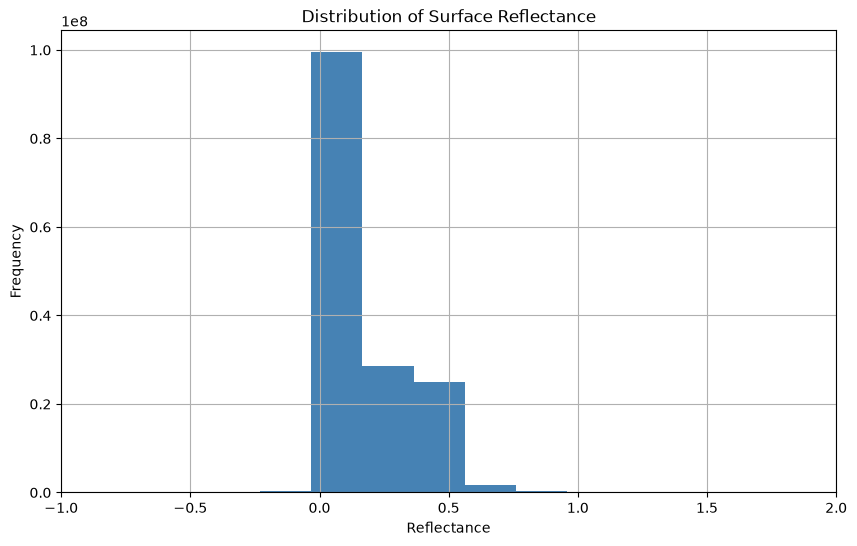

In [11]:
#7_Visulaize reflectance values
plt.figure(figsize=(10,6))

plt.hist(
    cube[~np.isnan(cube)].flatten(),
    bins=200,
    color="steelblue"
)

plt.title("Distribution of Surface Reflectance")

plt.xlabel("Reflectance")

plt.ylabel("Frequency")

plt.xlim(-1,2)

plt.grid(True)

plt.show()

In [15]:
#8_Percentiles
valid = cube[~np.isnan(cube)]

print("Percentiles")

for p in [0,1,5,25,50,75,95,99,100]:
    print(f"{p:>3}% : {np.percentile(valid,p):.4f}")

Percentiles
  0% : -15.8598
  1% : -0.0100
  5% : -0.0100
 25% : 0.0706
 50% : 0.1220
 75% : 0.2600
 95% : 0.4807
 99% : 0.5977
100% : 23.7111


In [16]:
#9_Find closest RGB bands
def find_band(target_nm):
    """Return the index of the band closest to a target wavelength."""
    return np.argmin(np.abs(wavelengths - target_nm))

red_band = find_band(650)
green_band = find_band(550)
blue_band = find_band(470)

print(f"Red   : Band {red_band} ({wavelengths[red_band]:.2f} nm)")
print(f"Green : Band {green_band} ({wavelengths[green_band]:.2f} nm)")
print(f"Blue  : Band {blue_band} ({wavelengths[blue_band]:.2f} nm)")

Red   : Band 55 (650.85 nm)
Green : Band 35 (550.84 nm)
Blue  : Band 19 (470.99 nm)


In [18]:
#10_Build the RGB image
rgb = np.dstack([
    cube[red_band],
    cube[green_band],
    cube[blue_band]
])

In [19]:
#11_Percentile stretch function
def stretch(image, lower=2, upper=98):
    image = image.copy()

    for i in range(image.shape[2]):

        band = image[:, :, i]

        p_low = np.nanpercentile(band, lower)
        p_high = np.nanpercentile(band, upper)

        band = np.clip(band, p_low, p_high)

        band = (band - p_low) / (p_high - p_low)

        image[:, :, i] = band

    return image

rgb_stretched = stretch(rgb)

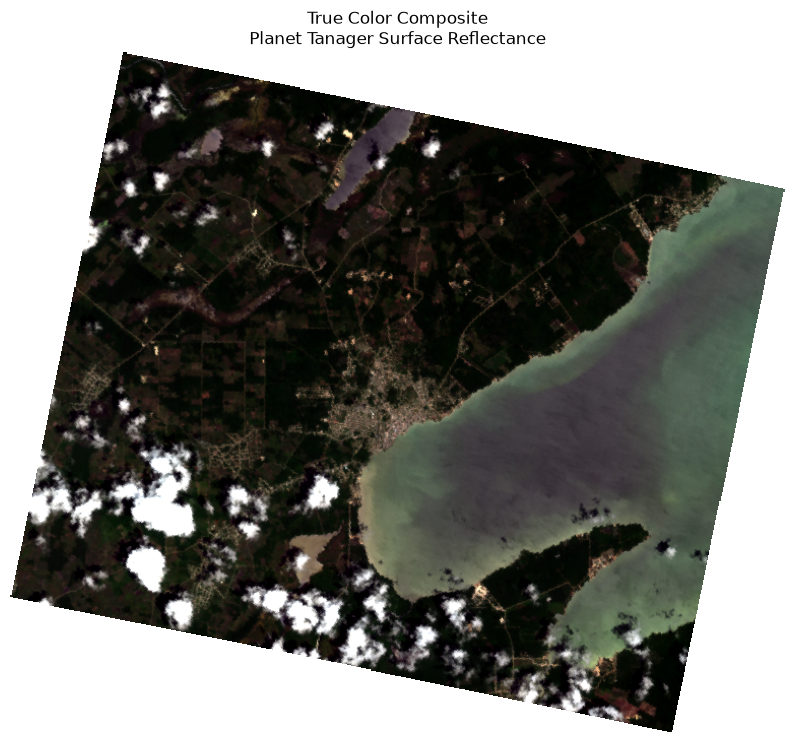

In [20]:
#12_Display RGB
plt.figure(figsize=(10,10))

plt.imshow(rgb_stretched)

plt.title("True Color Composite\nPlanet Tanager Surface Reflectance")

plt.axis("off")

plt.show()